# XGBoost regression

**Target:** `log_time = log(Time_Delta_sec)`  
**Features:**  
- `log_distance`, `log_weight`, `log_cube`, `log_quantity`  
- `Aisle_group`, `Level_group`, `time_of_day`...


In [147]:
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


In [148]:
# --- Paths (same as original notebook) ---
OE_PATH = Path("../data/processed/oe_detailed.parquet")
PICKTIME_PATH = Path("../data/processed/product_pick_times.csv")  # loaded for parity; optional downstream

# Load oe_detailed
oe = pd.read_parquet(OE_PATH)

# Ensure Timestamp is datetime
oe["Timestamp"] = pd.to_datetime(oe.get("Timestamp"), errors="coerce")
oe = oe.dropna(subset=["Timestamp"]).copy()

print("oe shape:", oe.shape)
print("Timestamp range:", oe["Timestamp"].min(), "->", oe["Timestamp"].max())
oe.head()


oe shape: (94402, 30)
Timestamp range: 2025-09-08 11:42:18.630000 -> 2025-12-02 23:15:28.677000


,ActivityCode,UserID,WorkCode,AssignmentID,ProductID,Quantity,Timestamp,LocationID,Prev_Timestamp,Prev_LocationID,...,Prev_Bay,Prev_Level,Prev_Slot,Aisle2,Bay2,Prev_Aisle2,Prev_Bay2,LocKey,PrevLocKey,Travel_Distance
0,PickPut,143,30,7717848,49658,160,2025-09-08 12:11:50.830,35192,NaT,<NA>,...,<NA>,<NA>,<NA>,40,19,<NA>,<NA>,40|19|||,<NA>|<NA>|||,NaN
1,PickPut,143,30,7717860,460,50,2025-09-08 12:12:18.127,422,2025-09-08 12:11:50.830,35192,...,19,2,2,40,18,40,19,40|18|||,40|19|||,21.0
2,PickPut,143,30,7717908,460,100,2025-09-08 12:15:46.650,422,2025-09-08 12:12:18.127,422,...,18,2,1,40,18,40,18,40|18|||,40|18|||,0.0
3,PickPut,143,30,7717921,44547,13,2025-09-08 12:16:30.470,10743,2025-09-08 12:15:46.650,422,...,18,2,1,40,18,40,18,40|18|||,40|18|||,0.0
4,PickPut,143,30,7717920,44547,13,2025-09-08 12:18:00.970,10743,2025-09-08 12:16:30.470,10743,...,18,2,2,40,18,40,18,40|18|||,40|18|||,0.0


In [149]:

# percentage of row with time < 600 seconds
print("Percentage of rows with Time_Delta_sec < 600:", (oe["Time_Delta_sec"] < 600).mean())
# percentage of row with time < 300 seconds
print("Percentage of rows with Time_Delta_sec < 300:", (oe["Time_Delta_sec"] < 300).mean())
# percentage of row with time < 180 seconds
print("Percentage of rows with Time_Delta_sec < 180:", (oe["Time_Delta_sec"] < 180).mean())

Percentage of rows with Time_Delta_sec < 600: 0.9827546026567233
Percentage of rows with Time_Delta_sec < 300: 0.9618969937077604
Percentage of rows with Time_Delta_sec < 180: 0.9314315374674266


In [150]:
# ---------- Feature engineering (same logic as oe_regression.ipynb) ----------
df = oe.copy()

# Ensure numerics
for col in ["Time_Delta_sec", "Weight", "Cube", "Quantity", "Travel_Distance"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Filter for log viability + WorkCode == '30'
df = df[
    (df["Time_Delta_sec"] > 0) &
    (df["Time_Delta_sec"] < 180) &
    (df["Travel_Distance"] >= 0) &
    (df["Weight"] > 0) &
    (df["Cube"] > 0) &
    (df["WorkCode"] == "30")
].copy()

# Aisle to int first
df["Aisle"] = pd.to_numeric(df["Aisle"], errors="coerce").fillna(-1).astype(int)
# Aisle as new column, group 10-19, 20-29, 30-38, 39-42, rest as "other"
'''
def aisle_group(a):
    if 10 <= a < 20:
        return "10-19"
    elif 20 <= a < 30:
        return "20-29"
    elif 30 <= a < 39:
        return "30-38"
    elif 39 <= a < 43:
        return "39-42"
    else:
        return "other"
df["Aisle_group"] = df["Aisle"].apply(aisle_group)
'''
# Actually for WC = 30, only 39, 40, 41, 42 are valid, so just these 4 or other
def aisle_group(a):
    if a in [39, 40, 41, 42]:
        return str(a)
    else:
        return "other"
df["Aisle_group"] = df["Aisle"].apply(aisle_group)

# Level categorical, 5 and above as "5+", rest as is
def level_group(l):
    if l in [5, 6, 7, 8, 9]:
        return "5+"
    else:
        return str(l)
df["Level_group"] = df["Level"].apply(level_group)

# Time of day (bucket)
df["hour"] = df["Timestamp"].dt.hour.astype(int)
def tod_bucket(h):
    if 6 <= h < 12:
        return "6-12"
    elif 12 <= h < 16:
        return "12-4"
    elif 16 <= h < 20:
        return "4-8"
    elif 20 <= h < 24:
        return "8-12"
    else:
        return "after_midnight"
df["time_of_day"] = df["hour"].apply(tod_bucket)

# Unit of Measure, 'EA', 'BX', 'PK', 'CA', CS, or group rest into other
def uom_group(u):
    if u in ['EA', 'BX', 'PK', 'CA', 'CS']:
        return u
    else:
        return "other"
df["UOM_group"] = df["UnitOfMeasure"].apply(uom_group)

# Day of week as levels
df["day_of_week"] = df["Timestamp"].dt.day_name()

# Add a feature same_aisle: 1 if Aisle and Prev_Aisle are the same, else 0
df["Prev_Aisle"] = pd.to_numeric(df["Prev_Aisle"], errors="coerce").fillna(-1).astype(int)
df["same_aisle"] = (df["Aisle"] == df["Prev_Aisle"]).astype(int)

# Add a feature if LocKey and Prev_LocKey are the same
df["same_lockey"] = (df["LocKey"] == df["PrevLocKey"]).astype(int)

# Add a feature if same lockey but differ in level
df["diff_level"] = ((df["LocKey"] == df["PrevLocKey"]) & (df["Level"] != df["Prev_Level"])).astype(int)

# Add a feature if ProductID in top 100 most common productid
product_counts = df["ProductID"].value_counts()
top_100_products = product_counts.head(100).index
df["top_100_product"] = df["ProductID"].isin(top_100_products).astype(int)

df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=[
    "Time_Delta_sec","Travel_Distance","Weight","Cube","Quantity",
    "Aisle_group","Level_group","time_of_day", "same_aisle", "same_lockey", "diff_level", 
    "UOM_group", "day_of_week", "top_100_product"
]).copy()

print("Modeling df shape:", df.shape)
df.head()


Modeling df shape: (61809, 40)


,ActivityCode,UserID,WorkCode,AssignmentID,ProductID,Quantity,Timestamp,LocationID,Prev_Timestamp,Prev_LocationID,...,Aisle_group,Level_group,hour,time_of_day,UOM_group,day_of_week,same_aisle,same_lockey,diff_level,top_100_product
1,PickPut,143,30,7717860,460,50,2025-09-08 12:12:18.127,422,2025-09-08 12:11:50.830,35192,...,40,2,12,12-4,EA,Monday,1,0,0,0
3,PickPut,143,30,7717921,44547,13,2025-09-08 12:16:30.470,10743,2025-09-08 12:15:46.650,422,...,40,2,12,12-4,EA,Monday,1,1,0,0
4,PickPut,143,30,7717920,44547,13,2025-09-08 12:18:00.970,10743,2025-09-08 12:16:30.470,10743,...,40,2,12,12-4,EA,Monday,1,1,0,0
5,PickPut,143,30,7717815,191,8,2025-09-08 12:18:45.173,2985,2025-09-08 12:18:00.970,10743,...,40,2,12,12-4,BX,Monday,1,0,0,0
6,PickPut,143,30,7717808,191,8,2025-09-08 12:19:12.290,2985,2025-09-08 12:18:45.173,2985,...,40,2,12,12-4,BX,Monday,1,1,0,0


In [151]:
# Split into train/test (same 80/20 random split)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (49447, 40)
Test shape: (12362, 40)


In [152]:
# ---------- Build design matrix (same feature set as Model 3: Lasso in the original) ----------
features = [
    "Travel_Distance", "Weight", "Cube", "Quantity",
    "Aisle_group", "Level_group",
    "time_of_day", "same_aisle", "same_lockey", "diff_level", "UOM_group", "day_of_week", "top_100_product"
]
cat_cols = ["Aisle_group", "Level_group", "time_of_day", "same_aisle", "same_lockey", "diff_level", "UOM_group", "day_of_week", "top_100_product"]

def build_X(df_in: pd.DataFrame) -> pd.DataFrame:
    X = df_in[features].copy()
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
    X = X.replace([np.inf, -np.inf], np.nan).fillna(0)
    return X.astype(float)

X_train = build_X(train_df)
X_test  = build_X(test_df)

# Align columns (important with one-hot)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

y_train = train_df["Time_Delta_sec"].astype(float).values
y_test  = test_df["Time_Delta_sec"].astype(float).values

print("X_train:", X_train.shape, "X_test:", X_test.shape)


X_train: (49447, 28) X_test: (12362, 28)


In [153]:
display(X_train.head())

,Travel_Distance,Weight,Cube,Quantity,Aisle_group_40,Aisle_group_41,Aisle_group_42,Aisle_group_other,Level_group_2,Level_group_3,...,diff_level_1,UOM_group_CA,UOM_group_CS,UOM_group_EA,UOM_group_PK,UOM_group_other,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,top_100_product_1
29432,0.0,0.0178,0.001,10.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
13356,0.0,0.0500,0.003,10.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
18910,0.0,0.0148,0.001,49.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
69469,0.0,4.0500,0.577,3.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
34344,24.0,0.2000,0.011,42.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [154]:
# ---------- XGBoost model (simple sklearn fit; no early stopping) ----------

from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

xgb = XGBRegressor(
    n_estimators=2000,          # keep reasonable since no early stopping
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="reg:tweedie",
    tweedie_variance_power=1.3,  # between 1 and 2
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_tr, y_tr)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=2000,
             n_jobs=-1, num_parallel_tree=None, ...)

In [155]:
# ---------- Evaluation ----------
pred = xgb.predict(X_test)

# Metrics
r2   = r2_score(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
mae  = mean_absolute_error(y_test, pred)

print("=== Test metrics===")
print(f"R^2   : {r2:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"MAE   : {mae:.4f}")

=== Test metrics===
R^2   : 0.4002
RMSE  : 26.6716
MAE   : 18.7104


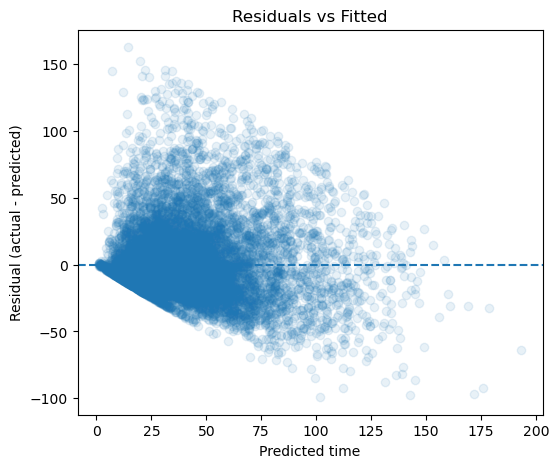

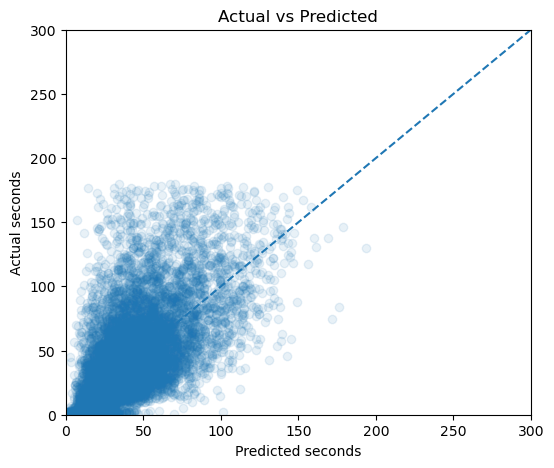

In [156]:
# ---------- Diagnostics plots ----------
resid = y_test - pred

# Residual vs fitted
plt.figure(figsize=(6,5))
plt.scatter(pred, resid, alpha=0.1)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted time")
plt.ylabel("Residual (actual - predicted)")
plt.title("Residuals vs Fitted")
plt.show()

# Actual vs predicted
lims = [0, 300]
plt.figure(figsize=(6,5))
plt.scatter(pred, y_test, alpha=0.1)
plt.xlim(lims)
plt.ylim(lims)
plt.plot(lims, lims, "--")
plt.xlabel("Predicted seconds")
plt.ylabel("Actual seconds")
plt.title("Actual vs Predicted")
plt.show()


,feature,importance
17,same_lockey_1,0.161735
18,diff_level_1,0.149615
16,same_aisle_1,0.088619
0,Travel_Distance,0.082649
7,Aisle_group_other,0.049384
3,Quantity,0.041588
27,top_100_product_1,0.032980
21,UOM_group_EA,0.030070
2,Cube,0.024306
6,Aisle_group_42,0.024029


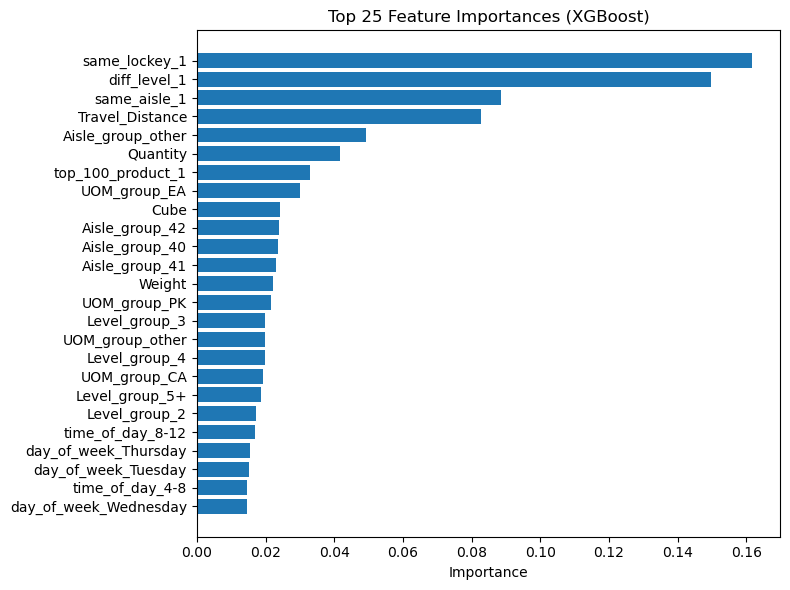

In [157]:
# ---------- Feature importance ----------
# Gain-based importance
importances = xgb.feature_importances_
imp = (
    pd.DataFrame({"feature": X_train.columns, "importance": importances})
    .sort_values("importance", ascending=False)
)

display(imp.head(25))

plt.figure(figsize=(8,6))
plt.barh(imp.head(25)["feature"][::-1], imp.head(25)["importance"][::-1])
plt.title("Top 25 Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()